### 🚀 For an interactive experience, head over to our [demo platform](https://var.vision/demo) and dive right in! 🌟

In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Using device: {device}')

Using device: cuda


In [2]:
## set cuda device

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [8]:
################## 1. Download checkpoints and build models
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw
from IPython.display import display, Image
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)     # disable default parameter init for faster speed
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)  # disable default parameter init for faster speed
from var_models import VQVAE, build_vae_var
from tqdm import tqdm

MODEL_DEPTH = 16    # TODO: =====> please specify MODEL_DEPTH <=====
assert MODEL_DEPTH in {12, 16, 20, 24, 30}

V=4096
model_version = 'best'

# download checkpoint
# hf_home = 'https://huggingface.co/FoundationVision/var/resolve/main'
# vae_ckpt, var_ckpt = './taming-transformers/logs/2025-05-12T21-53-13_multiscale_vqvae/checkpoints/last.ckpt', f'./local_output/tb-VARd16__pn1_2_3_4_5_6_8__b384ep500adamlr0.0001wd0.05__V1024/ar-ckpt-{model_version}.pth'
vae_ckpt, var_ckpt = './taming-transformers/logs/2025-05-09T03-58-14_multiscale_vqvae/checkpoints/last.ckpt', f'./local_output/tb-VARd16__pn1_2_3_4_5_6_8__b384ep500adamlr0.0001wd0.05__V4096/ar-ckpt-{model_version}.pth'
# vae_ckpt, var_ckpt = 'vae_ch160v4096z32.pth', './local_output/ar-ckpt-best_VAR_d12.pth'
# vae_ckpt, var_ckpt = 'vae_ch160v4096z32.pth', './local_output/ar-ckpt-best_VAR_d12.pth'
# vae_ckpt, var_ckpt = 'vae_ch160v4096z32.pth', './local_output/ar-ckpt-best.pth'
# if not osp.exists(vae_ckpt): os.system(f'wget {hf_home}/{vae_ckpt}')
# if not osp.exists(var_ckpt): os.system(f'wget {hf_home}/{var_ckpt}')

if not osp.exists(vae_ckpt): print('vae_ckpt does not exist')
if not osp.exists(var_ckpt): print('var_ckpt does not exist')

# build vae, var
# patch_nums = (1, 2, 3, 4, 5, 6, 8, 10, 13, 16)
patch_nums = (1, 2, 3, 4, 5, 6, 8)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# if 'vae' not in globals() or 'var' not in globals():
vae, var = build_vae_var(
    V=V, Cvae=32, ch=128, share_quant_resi=4,    # hard-coded VQVAE hyperparameters
    device=device, patch_nums=patch_nums,
    num_classes=1000, depth=MODEL_DEPTH, shared_aln=False,
)

# load checkpoints
vae.load_state_dict(torch.load(vae_ckpt, map_location='cpu')['state_dict'], strict=False)
var.load_state_dict(torch.load(var_ckpt, map_location='cpu')['trainer']['var_wo_ddp'], strict=True)
vae.eval(), var.eval()
for p in vae.parameters(): p.requires_grad_(False)
for p in var.parameters(): p.requires_grad_(False)
print(f'prepare finished.')


[constructor]  ==== flash_if_available=True (16/16), fused_if_available=True (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0666667 (tensor([0.0000, 0.0044, 0.0089, 0.0133, 0.0178, 0.0222, 0.0267, 0.0311, 0.0356,
        0.0400, 0.0444, 0.0489, 0.0533, 0.0578, 0.0622, 0.0667]))

[init_weights] VAR with init_std=0.0180422
prepare finished.


In [5]:
torch.cuda.is_available()

True

100%|██████████| 5000/5000 [07:17<00:00, 11.43it/s]


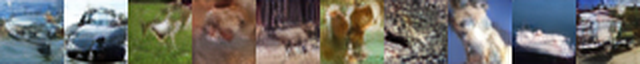

100%|██████████| 5000/5000 [07:17<00:00, 11.43it/s]


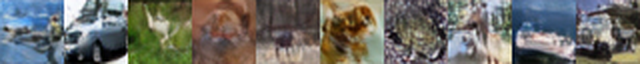

100%|██████████| 5000/5000 [07:17<00:00, 11.42it/s]


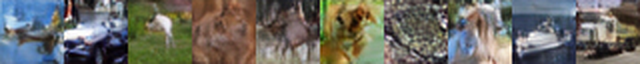

100%|██████████| 5000/5000 [07:20<00:00, 11.36it/s]


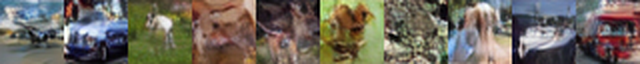

100%|██████████| 5000/5000 [07:21<00:00, 11.33it/s]


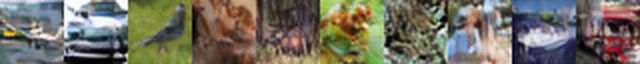

100%|██████████| 5000/5000 [07:20<00:00, 11.35it/s]


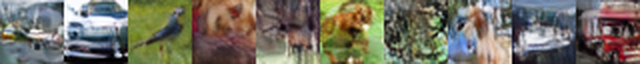

100%|██████████| 5000/5000 [07:20<00:00, 11.36it/s]


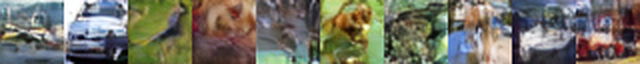

100%|██████████| 5000/5000 [07:19<00:00, 11.38it/s]


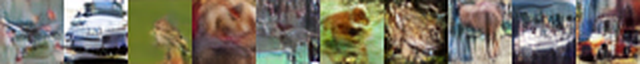

In [10]:
############################# 2. Sample with classifier-free guidance

# set args
seed = 1 #@param {type:"number"}
torch.manual_seed(seed)
num_sampling_steps = 250 #@param {type:"slider", min:0, max:1000, step:1}
cfg = 2.5 #@param {type:"slider", min:1, max:10, step:0.1}
# class_labels = (980, 980, 437, 437, 22, 22, 562, 562)  #@param {type:"raw"}
class_labels = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
# class_labels = (130, 270, 88, 284, 688, 250, 146, 980, 484) 

save_tensor = True
more_smooth = False if save_tensor else True # True for more smooth output

num_samples = 5000

list_of_chw = []
recon_B3HW_dict = {}

for cfg in [1, 2, 3, 4, 5, 6, 7, 8]:

    # seed
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # run faster
    tf32 = True
    torch.backends.cudnn.allow_tf32 = bool(tf32)
    torch.backends.cuda.matmul.allow_tf32 = bool(tf32)
    torch.set_float32_matmul_precision('high' if tf32 else 'highest')

    # sample
    B = len(class_labels)
    label_B: torch.LongTensor = torch.tensor(class_labels, device=device)
    with torch.inference_mode():
        with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):    # using bfloat16 can be faster
            if save_tensor:
                samples = []
                for i in tqdm(range(num_samples)):
                    recon_B3HW = var.autoregressive_infer_cfg(B=B, label_B=label_B, cfg=cfg, top_k=900, top_p=0.95, g_seed=seed, more_smooth=more_smooth)
                    samples.append(recon_B3HW)
                recon_B3HW_dict[cfg] = samples
            else:
                recon_B3HW = var.autoregressive_infer_cfg(B=B, label_B=label_B, cfg=cfg, top_k=900, top_p=0.95, g_seed=seed, more_smooth=more_smooth)
        
    

    chw = torchvision.utils.make_grid(recon_B3HW, nrow=10, padding=0, pad_value=1.0)
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    chw = PImage.fromarray(chw.astype(np.uint8))
    chw = chw.resize((chw.width * 2, chw.height * 2), PImage.Resampling.LANCZOS) 
    display(chw)
    # display(Image(data=chw.tobytes(), width=500))

    list_of_chw.append(chw)
    if save_tensor:
        torch.save(recon_B3HW_dict, os.path.join(os.path.dirname(var_ckpt), f'recon_B3HW_dict_d16_V{V}_{model_version}_cfg.pth'))
if save_tensor:
    torch.save(recon_B3HW_dict, os.path.join(os.path.dirname(var_ckpt), f'recon_B3HW_dict_d16_V{V}_{model_version}_cfg.pth'))
else:
    for idx, cfg in enumerate([1, 2, 3, 4, 5, 6, 7, 8]):
        list_of_chw[idx].save(os.path.join(os.path.dirname(var_ckpt), f'recon_B3HW_dict_d16_V{V}_{model_version}_cfg_{cfg}.png'))


In [12]:
for i in range(len(list_of_chw)):
    list_of_chw[i].show()

In [ ]:
chw

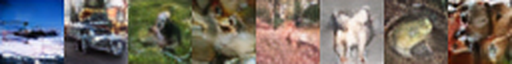

In [31]:
############################# 3. Sample without classifier-free guidance

# set args
seed = 1 #@param {type:"number"}
torch.manual_seed(seed)
num_sampling_steps = 250 #@param {type:"slider", min:0, max:1000, step:1}
cfg = 2.5 #@param {type:"slider", min:1, max:10, step:0.1}
# class_labels = (980, 980, 437, 437, 22, 22, 562, 562)  #@param {type:"raw"}
class_labels = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
# class_labels = (130, 270, 88, 284, 688, 250, 146, 980, 484) 
save_tensor = True
more_smooth = False if save_tensor else True # True for more smooth output

# seed
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# run faster
tf32 = True
torch.backends.cudnn.allow_tf32 = bool(tf32)
torch.backends.cuda.matmul.allow_tf32 = bool(tf32)
torch.set_float32_matmul_precision('high' if tf32 else 'highest')

# sample
# B = len(class_labels)
# label_B: torch.LongTensor = torch.tensor(class_labels, device=device)
# with torch.inference_mode():
#     with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):    # using bfloat16 can be faster
#         recon_B3HW = var.autoregressive_infer_cfg(B=B, label_B=label_B, cfg=cfg, top_k=900, top_p=0.95, g_seed=seed, more_smooth=more_smooth)

B = len(class_labels)
label_B: torch.LongTensor = torch.tensor(class_labels, device=device)
with torch.inference_mode():
    with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):    # using bfloat16 can be faster
        if save_tensor:
            samples = []
            for i in tqdm(range(num_samples)):
                recon_B3HW = var.autoregressive_infer_cfg(B=B, label_B=label_B, cfg=cfg, top_k=900, top_p=0.95, g_seed=seed, more_smooth=more_smooth)
                samples.append(recon_B3HW)
            recon_B3HW_dict[cfg] = samples
        else:
            recon_B3HW = var.autoregressive_infer_cfg(B=B, label_B=label_B, cfg=cfg, top_k=900, top_p=0.95, g_seed=seed, more_smooth=more_smooth)

chw = torchvision.utils.make_grid(recon_B3HW, nrow=8, padding=0, pad_value=1.0)
chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
chw = PImage.fromarray(chw.astype(np.uint8))
chw = chw.resize((chw.width * 2, chw.height * 2), PImage.Resampling.LANCZOS) 
display(chw)
# chw.show()

if save_tensor:
    torch.save(recon_B3HW_dict, os.path.join(os.path.dirname(var_ckpt), f'recon_B3HW_d16_V{V}_{model_version}.pth'))
else:
    chw.save(os.path.join(os.path.dirname(var_ckpt), f'recon_B3HW_d16_V{V}_{model_version}.png'))


In [ ]:
chw

In [ ]:
################## 1. Download checkpoints and build models
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)     # disable default parameter init for faster speed
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)  # disable default parameter init for faster speed
from models import VQVAE, build_vae_var

MODEL_DEPTH = 16    # TODO: =====> please specify MODEL_DEPTH <=====
assert MODEL_DEPTH in {16, 20, 24, 30}

# download checkpoint
hf_home = 'https://huggingface.co/FoundationVision/var/resolve/main'
vae_ckpt, var_ckpt = 'vae_ch160v4096z32.pth', f'var_d{MODEL_DEPTH}.pth'
if not osp.exists(vae_ckpt): os.system(f'wget {hf_home}/{vae_ckpt}')
if not osp.exists(var_ckpt): os.system(f'wget {hf_home}/{var_ckpt}')

# build vae, var
patch_nums = (1, 2, 3, 4, 5, 6, 8, 10, 13, 16)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if 'vae' not in globals() or 'var' not in globals():
    vae, var = build_vae_var(
        V=4096, Cvae=32, ch=160, share_quant_resi=4,    # hard-coded VQVAE hyperparameters
        device=device, patch_nums=patch_nums,
        num_classes=1000, depth=MODEL_DEPTH, shared_aln=False,
    )

# load checkpoints
vae.load_state_dict(torch.load(vae_ckpt, map_location='cpu'), strict=True)
var.load_state_dict(torch.load(var_ckpt, map_location='cpu'), strict=True)
vae.eval(), var.eval()
for p in vae.parameters(): p.requires_grad_(False)
for p in var.parameters(): p.requires_grad_(False)
print(f'prepare finished.')